# **Разведочный анализ данных**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

### **1. Первичный обзор**

In [2]:
df = pd.read_csv('../data/data.csv', sep =';')
# df = df[df['Degree of stenosis']<0.9]
df.head()

,Re,Stenosis length [cm],Radius [cm],Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference [dyn/cm^2]
0,30,0.75,0.15,5.0,0.0,1.0,97
1,50,0.75,0.15,5.0,0.0,1.0,156
2,100,0.75,0.15,5.0,0.0,1.0,314
3,200,0.75,0.15,5.0,0.0,1.0,623
4,300,0.75,0.15,5.0,0.0,1.0,939


In [3]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['Re', 'Stenosis length [cm]', 'Radius [cm]', 'Stenosis length/Radius', 'Degree of stenosis', 'Asymmetry', 'Pressure difference [dyn/cm^2]']


In [4]:
print(f'Размер датасета: {df.shape}')

Размер датасета: (1800, 7)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Re                              1800 non-null   int64  
 1   Stenosis length [cm]            1800 non-null   float64
 2   Radius [cm]                     1800 non-null   float64
 3   Stenosis length/Radius          1800 non-null   float64
 4   Degree of stenosis              1800 non-null   float64
 5   Asymmetry                       1800 non-null   float64
 6   Pressure difference [dyn/cm^2]  1800 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 98.6 KB


In [6]:
print('Пропуски:')
print('-'*50)
miss = df.isna().mean()
miss

Пропуски:
--------------------------------------------------


Re                                0.0
Stenosis length [cm]              0.0
Radius [cm]                       0.0
Stenosis length/Radius            0.0
Degree of stenosis                0.0
Asymmetry                         0.0
Pressure difference [dyn/cm^2]    0.0
dtype: float64

In [7]:
dup = df.duplicated().sum()
print(f'Дубликаты: {dup}')

Дубликаты: 0


**Итог**:
* Размер датасета (1800, 7)
* Переменные все числовые
* В данных отсутствуют пропуски и дубликаты

### **2. Описательная статистика**

In [8]:
df.describe()

,Re,Stenosis length [cm],Radius [cm],Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference [dyn/cm^2]
count,1800.000000,1800.000000,1.800000e+03,1800.000000,1800.000000,1800.000000,1.800000e+03
mean,368.000000,2.062500,1.500000e-01,13.750000,0.450000,0.500000,1.701574e+06
std,262.591523,1.399328,2.776329e-17,9.328854,0.287308,0.408362,6.816909e+06
min,30.000000,0.375000,1.500000e-01,2.500000,0.000000,0.000000,8.100000e+01
25%,100.000000,0.750000,1.500000e-01,5.000000,0.200000,0.000000,1.994000e+03
50%,350.000000,1.875000,1.500000e-01,12.500000,0.450000,0.500000,9.109000e+03
75%,600.000000,3.000000,1.500000e-01,20.000000,0.700000,1.000000,1.158048e+05
max,800.000000,4.500000,1.500000e-01,30.000000,0.900000,1.000000,5.317556e+07


### **3. Анализ целевой переменной**

#### **3.1. Распределенее**

Text(0.5, 1.0, 'Распределение перепада давления')

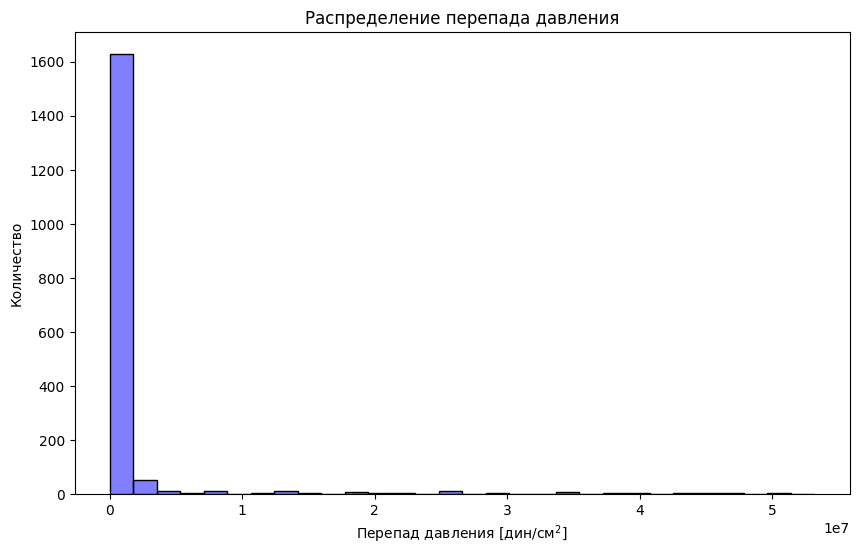

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['Pressure difference [dyn/cm^2]'],color = 'blue', alpha = 0.5, bins=30, kde=False)
plt.xlabel('Перепад давления [дин/см$^2$]')  # красиво отображается
plt.ylabel("Количество")
plt.title("Распределение перепада давления")


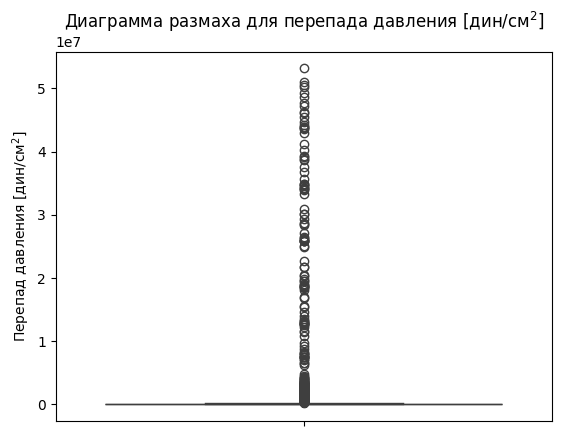

In [10]:
sns.boxplot(y=df['Pressure difference [dyn/cm^2]'])
plt.title('Диаграмма размаха для перепада давления [дин/см$^2$]')
plt.ylabel('Перепад давления [дин/см$^2$]')  # красиво отображается

plt.show()

Непрерывное правоскошенное распределение с длинным правым хвостом, основные значения сосредоточены ближе к нулю.  
При обучении моделей в исходной шкале крупные значения ΔP будут доминоровать в функции потерь, что ухудшает качество в области малых и средних значений.

#### **3.2. Преобразование целевой переменной**

**Log-пространство:**

In [11]:
log_df = np.log1p(df['Pressure difference [dyn/cm^2]'])

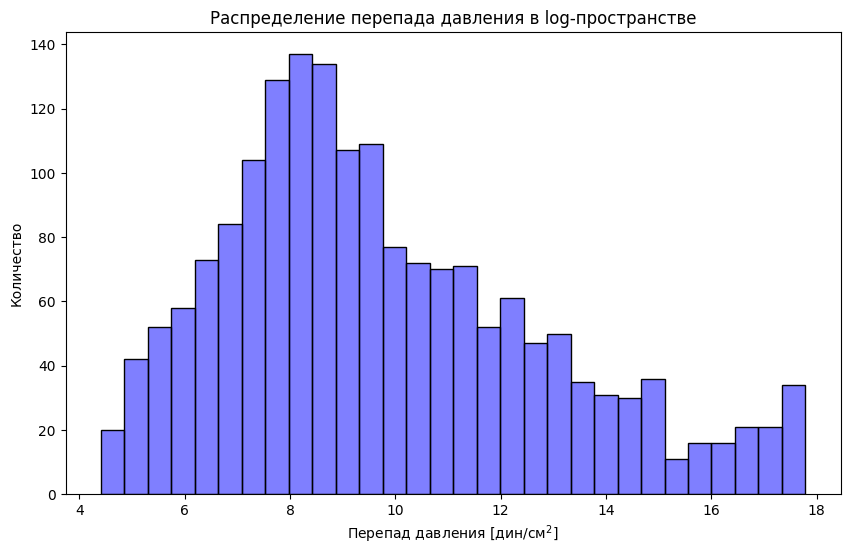

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(log_df,color = 'blue', alpha = 0.5, bins=30, kde=False)
plt.ylabel("Количество")
plt.xlabel('Перепад давления [дин/см$^2$]')
plt.title("Распределение перепада давления в log-пространстве")
plt.show()

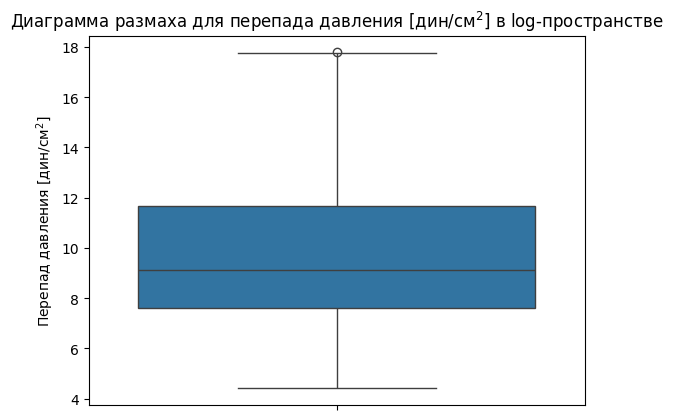

In [13]:
sns.boxplot(y=log_df)
plt.ylabel('Перепад давления [дин/см$^2$]')
plt.title('Диаграмма размаха для перепада давления [дин/см$^2$] в log-пространстве')
plt.show()

При логарифмировании получились следующие результаты:
* диапазон сжался
* распределение стало ближе к нормальному, один основной пик и плавный хвост

**Обезразмеривание целевой переменной:**

Параметры моделирования крови в системе СГС

Для математического моделирования гидродинамики крови используются следующие физические характеристики:

1. Плотность ($\rho$)
$\rho = 1.05$ г/см³.  
Это стандартная величина для цельной крови, которая чуть выше плотности воды ($1.0$ г/см³) из-за наличия форменных элементов (эритроцитов, лейкоцитов и т.д.).

2. Динамическая вязкость ($\mu$)
$\mu = 0.035$ г/(см·с) или **Пуаз** (П).  
Вязкость определяет внутреннее трение жидкости. Значение $0.035$ характерно для крови при нормальном уровне гематокрита и высокой скорости сдвига (ньютоновская аппроксимация).



In [14]:
rho = 1.05
mu = 0.035

df["Velocity [cm/s]"] = df["Re"] * mu / (2 * rho * df["Radius [cm]"])
df["rho*Velocity^2"] = rho * df["Velocity [cm/s]"]**2
df['Pressure difference norm'] = df['Pressure difference [dyn/cm^2]']/df["rho*Velocity^2"]

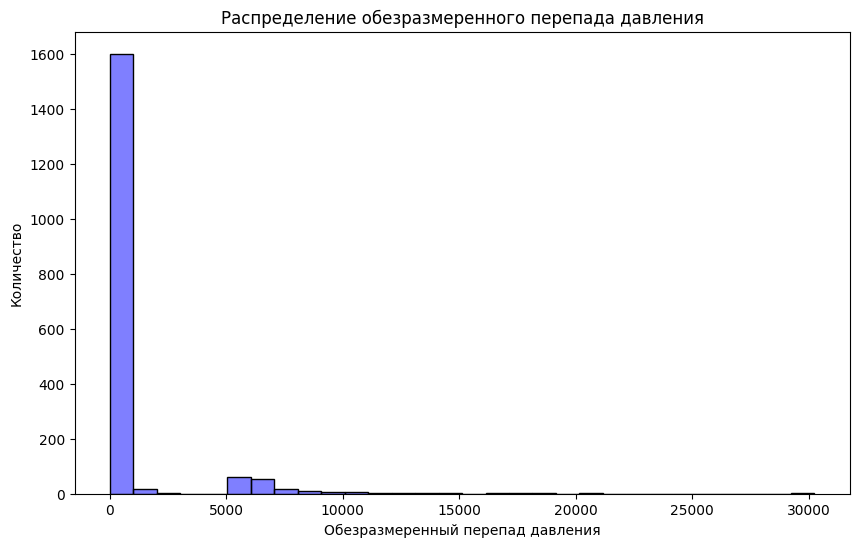

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Pressure difference norm'],color = 'blue', alpha = 0.5, bins=30, kde=False)
plt.ylabel("Количество")
plt.xlabel("Обезразмеренный перепад давления")
plt.title("Распределение обезразмеренного перепада давления")
plt.show()

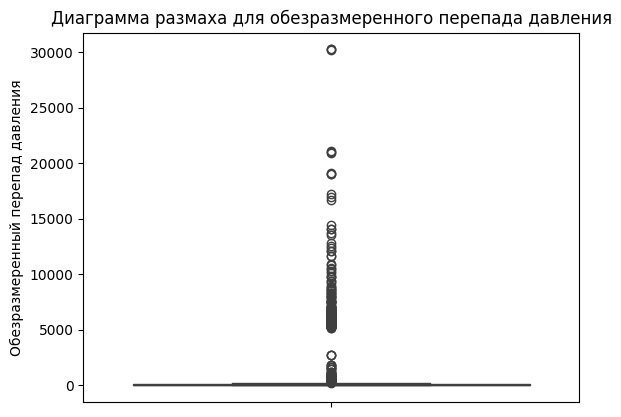

In [16]:
sns.boxplot(y=df['Pressure difference norm'])
plt.title('Диаграмма размаха для обезразмеренного перепада давления')
plt.ylabel('Обезразмеренный перепад давления')  # красиво отображается

plt.show()

Основные отличия между исходным диапазоном перепада давления и обезразмеренным:
* диапазон сжался
* распределение остаётся правосторонне асимметричным.

**Обезразмеривание и перевод в log-пространство целевой переменной:**

In [17]:
log_norm_df = np.log1p(df['Pressure difference norm'])

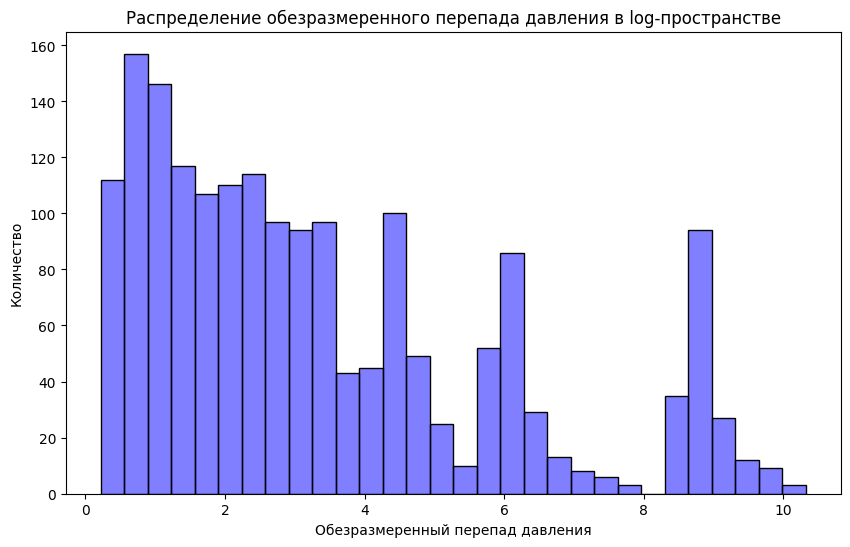

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(log_norm_df,color = 'blue', alpha = 0.5, bins=30, kde=False)
plt.ylabel("Количество")
plt.xlabel("Обезразмеренный перепад давления")
plt.title("Распределение обезразмеренного перепада давления в log-пространстве")
plt.show()

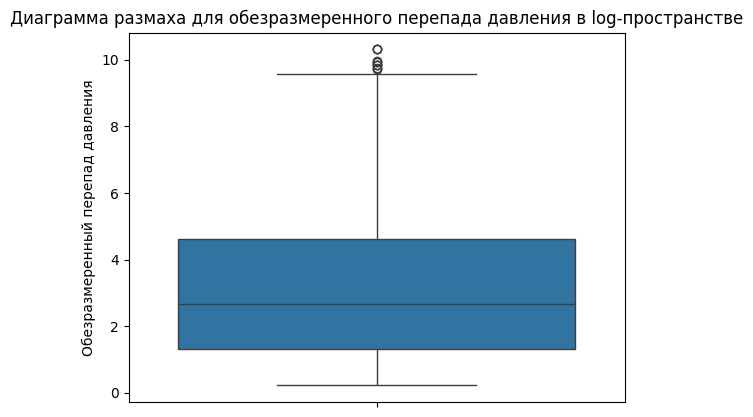

In [19]:
sns.boxplot(y=log_norm_df)
plt.ylabel('Обезразмеренный перепад давления')
plt.title('Диаграмма размаха для обезразмеренного перепада давления в log-пространстве')
plt.show()

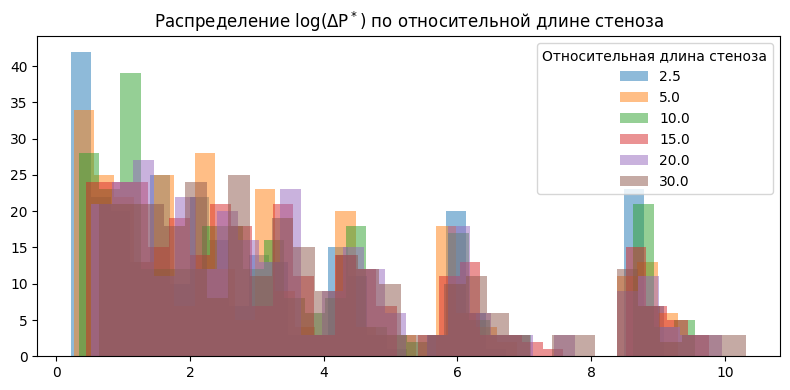

In [20]:
ylog = np.log1p(df["Pressure difference norm"].clip(lower=1e-12))

plt.figure(figsize=(8,4))
for a, tmp in df.groupby("Stenosis length/Radius"):
    plt.hist(ylog.loc[tmp.index], bins=30, alpha=0.5, label=str(a))
plt.legend(title="Относительная длина стеноза")
plt.title("Распределение log(ΔP$^*$) по относительной длине стеноза")
plt.tight_layout()
plt.show()

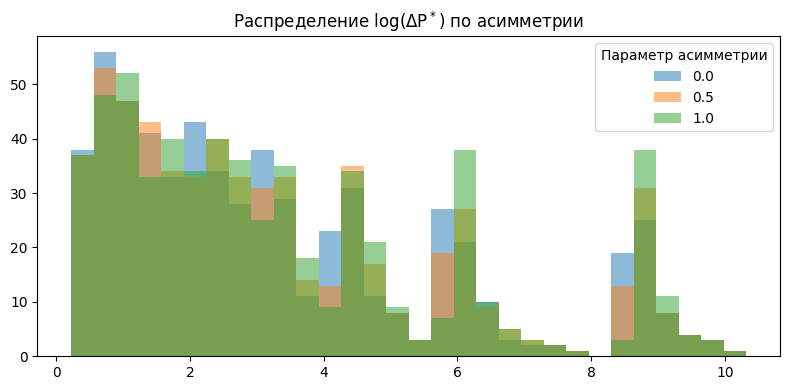

In [21]:
ylog = np.log1p(df["Pressure difference norm"].clip(lower=1e-12))

plt.figure(figsize=(8,4))
for a, tmp in df.groupby("Asymmetry"):
    plt.hist(ylog.loc[tmp.index], bins=30, alpha=0.5, label=str(a))
plt.legend(title="Параметр асимметрии")
plt.title("Распределение log(ΔP$^*$) по асимметрии")
plt.tight_layout()
plt.show()


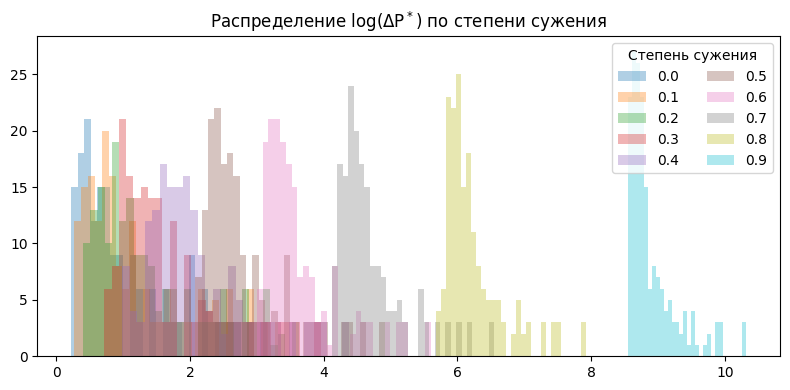

In [22]:
col = "Degree of stenosis"
ylog = np.log1p(df["Pressure difference norm"])

plt.figure(figsize=(8,4))
for g, tmp in df.groupby(col):
    plt.hist(ylog.loc[tmp.index], bins=30, alpha=0.35, label=str(g))
plt.legend(title='Степень сужения', ncol=2)
plt.title(f"Распределение log(ΔP$^*$) по степени сужения")
plt.tight_layout()
plt.show()


Основные характеристики логарифмирования обезразмеренной переменной:
* Мультимодальность, основной фактор которой - степень сужения. На графике "Распределение log(ΔP_norm) по степени сужения" каждый уровень степени стеноза даёт свой отдельный диапазон, и чем выше степень, тем сильнее сдвиг вправо.
* На графике "Распределение log(ΔP_norm) по асимметрии" три распределения почти полностью накладываются. Это означает, что асимметрия не является основным фактором, разделяющим режимы в распределении.

**Сравнение обезразмеренного перепада давления в исходном и log-пространстве:**

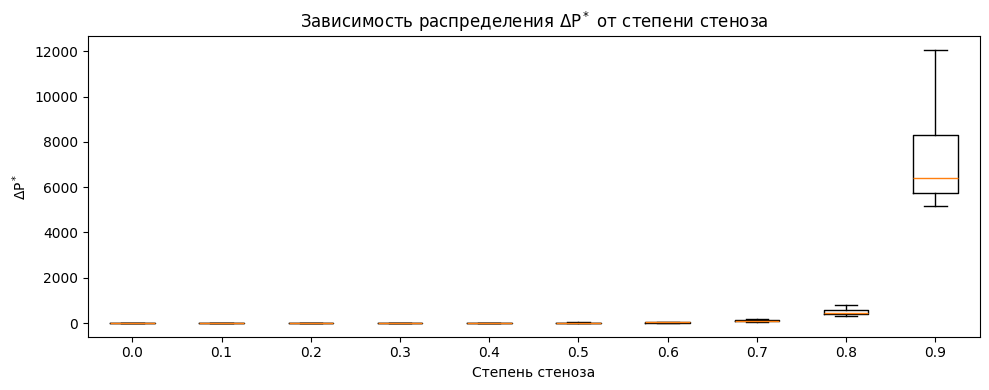

In [23]:
ylog = (df["Pressure difference norm"])
deg = "Degree of stenosis"

cats = sorted(df[deg].unique())
data = [ylog[df[deg]==c].values for c in cats]

plt.figure(figsize=(10,4))
plt.boxplot(data, tick_labels=cats, showfliers=False)
plt.xlabel("Степень стеноза")
plt.ylabel("ΔP$^*$")
plt.title("Зависимость распределения ΔP$^*$ от степени стеноза")
plt.tight_layout()
plt.show()


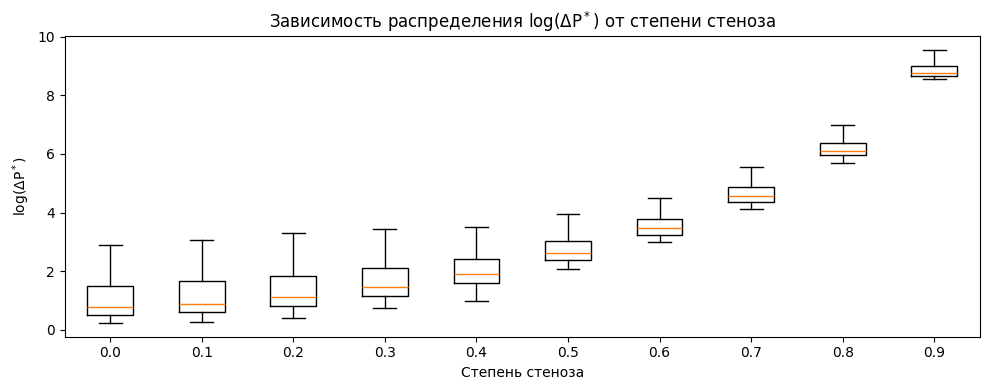

In [24]:
ylog = np.log1p(df["Pressure difference norm"])
deg = "Degree of stenosis"

cats = sorted(df[deg].unique())
data = [ylog[df[deg]==c].values for c in cats]

plt.figure(figsize=(10,4))
plt.boxplot(data, tick_labels=cats, showfliers=False)
plt.xlabel("Степень стеноза")
plt.ylabel("log(ΔP$^*$)")
plt.title("Зависимость распределения log(ΔP$^*$) от степени стеноза")
plt.tight_layout()
plt.show()


* При больших степенях (0.8–0.9) в исходном пространстве значения взлетают на порядки. Из-за этого всё, что происходит при 0.0–0.7, прижато к нулю.
* Для лог-пространства разброс внутри группы остаётся относительно контролируемым и сравнимым по масштабам между степенями

**Потенциальная проблема:** в исходной шкале модель с MSE будет учиться на больших степенях, а малые будут игнорироваться.

### **4. Анализ признаков**

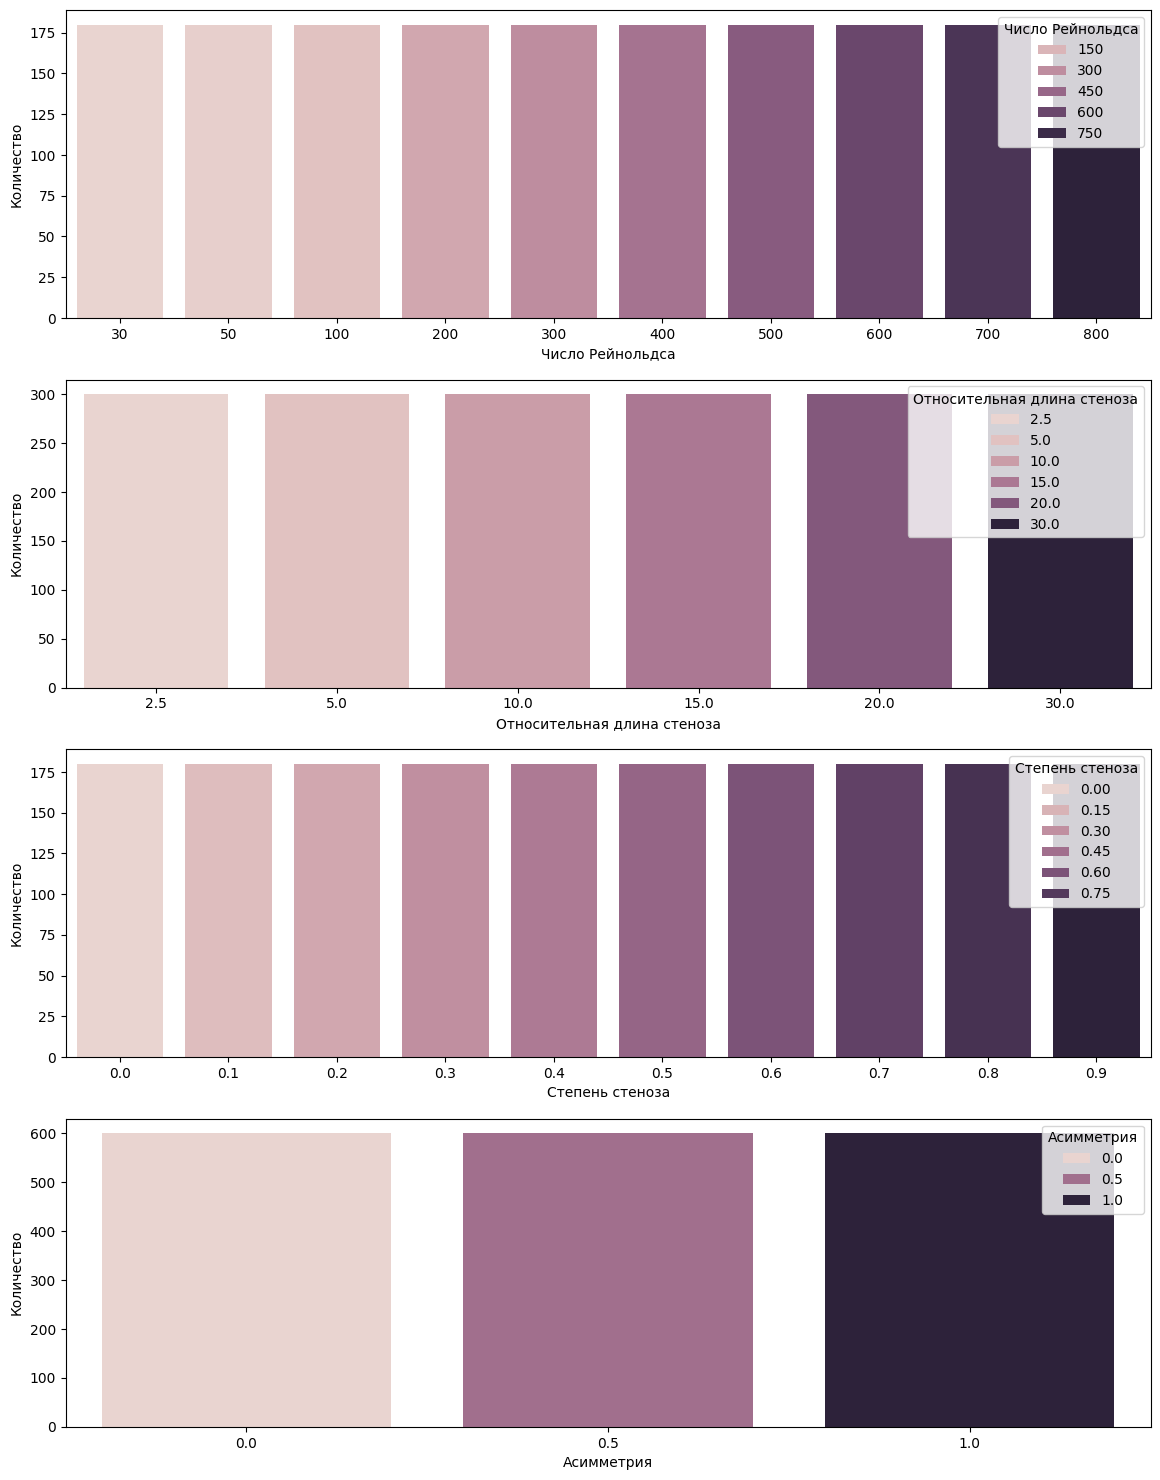

In [25]:
cols = ['Re','Stenosis length/Radius','Degree of stenosis','Asymmetry']

nice_names = {
    'Re': 'Число Рейнольдса',
    'Stenosis length/Radius': 'Относительная длина стеноза',
    'Degree of stenosis': 'Степень стеноза',
    'Asymmetry': 'Асимметрия'
}

plt.figure(figsize=(14,28))

for i, col in enumerate(cols):
    plt.subplot(6,1,i+1)
    sns.countplot(data=df, x=col, hue=col)
    plt.xlabel(nice_names[col])   # ← вот тут подмена
    plt.ylabel('Количество')
    plt.legend(title=nice_names[col])

Набор данных сформирован по сеточному плану: для каждого фиксированного уровня параметров (Re, длина стеноза, степень стеноза, асимметрия) число наблюдений одинаково, что исключает перекосы частот.

### **5. Корреляционный анализ**

In [26]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Re', 'Stenosis length [cm]', 'Radius [cm]', 'Stenosis length/Radius',
       'Degree of stenosis', 'Asymmetry', 'Pressure difference [dyn/cm^2]',
       'Velocity [cm/s]', 'rho*Velocity^2', 'Pressure difference norm'],
      dtype='object')>

In [27]:
df_num = df.drop(['Radius [cm]', 'Stenosis length [cm]', 'Velocity [cm/s]',
       'rho*Velocity^2'], axis=1)

In [28]:
corr_pearson = df_num.corr(method='pearson')
corr_spearman = df_num.corr(method='spearman')

In [29]:
nice_names = {
    'Re': 'Re',
    'Stenosis length/Radius': '$\\frac{L_{stenosis}}{R_{healthy}}$',
    'Degree of stenosis': 'S',
    'Asymmetry': r'$\alpha$',
    'Pressure difference [dyn/cm^2]': r'$\Delta P$',
    'Pressure difference norm': r'$\Delta P^*$'
}

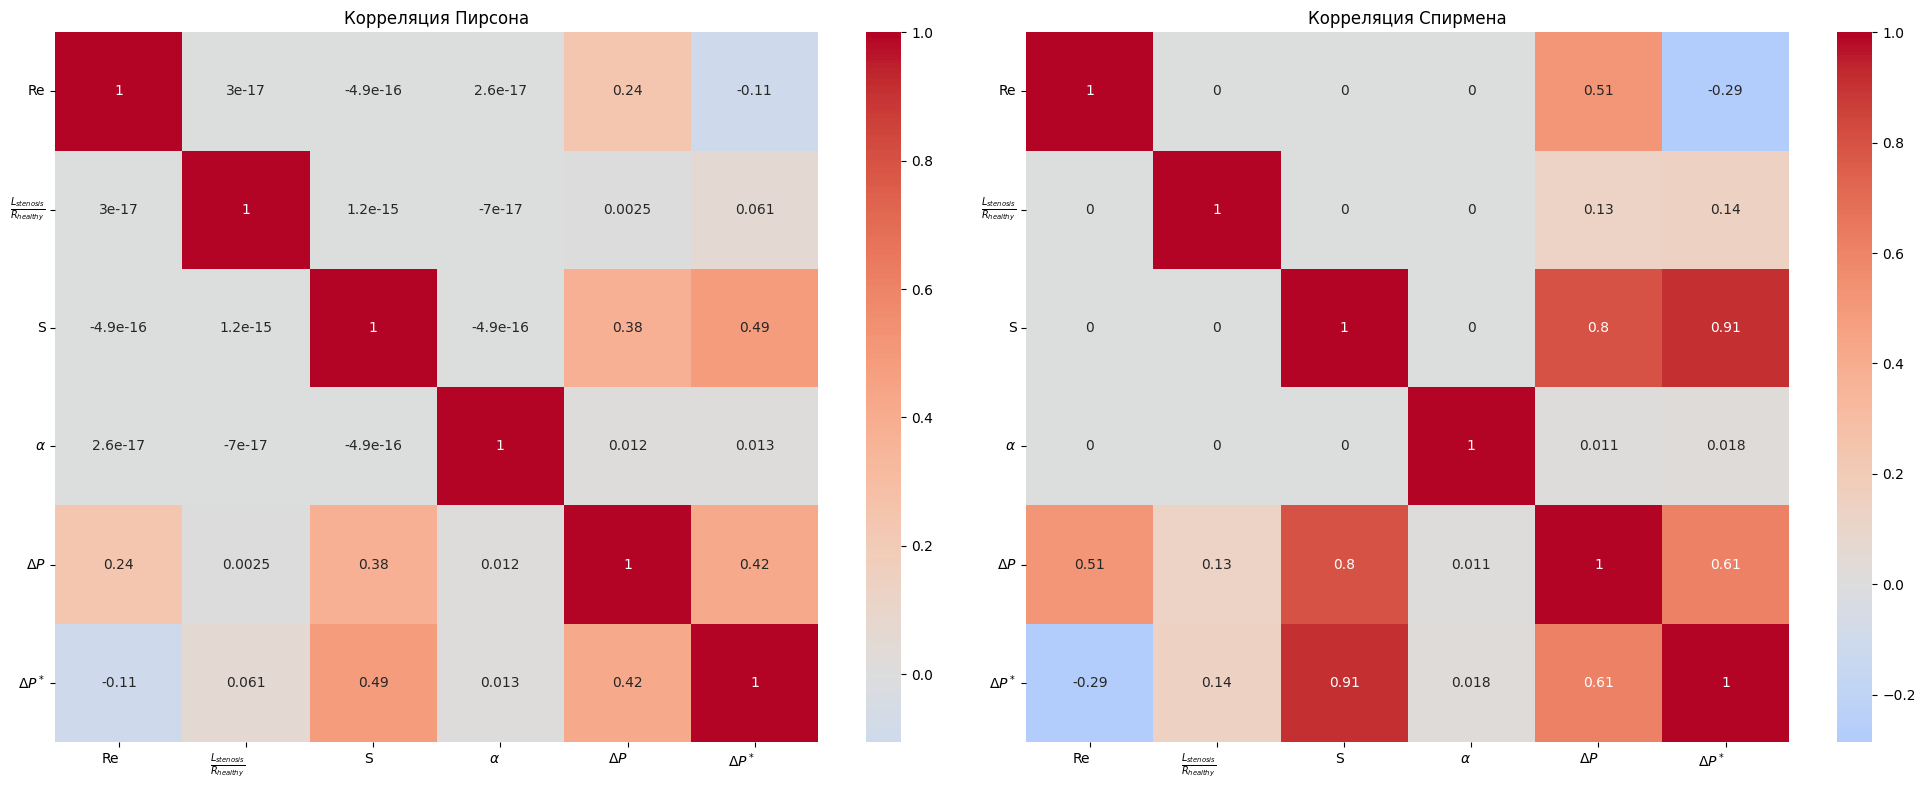

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Корреляция Пирсона')

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Корреляция Спирмена')

# замена подписей
for ax in axes:
    labels = [nice_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=0, ha='right')

    labels = [nice_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

In [31]:
df_num_log = df_num
df_num_log['Pressure difference [dyn/cm^2]'] = np.log1p(df_num['Pressure difference [dyn/cm^2]'])
df_num_log['Pressure difference norm'] = np.log1p(df_num['Pressure difference norm'])

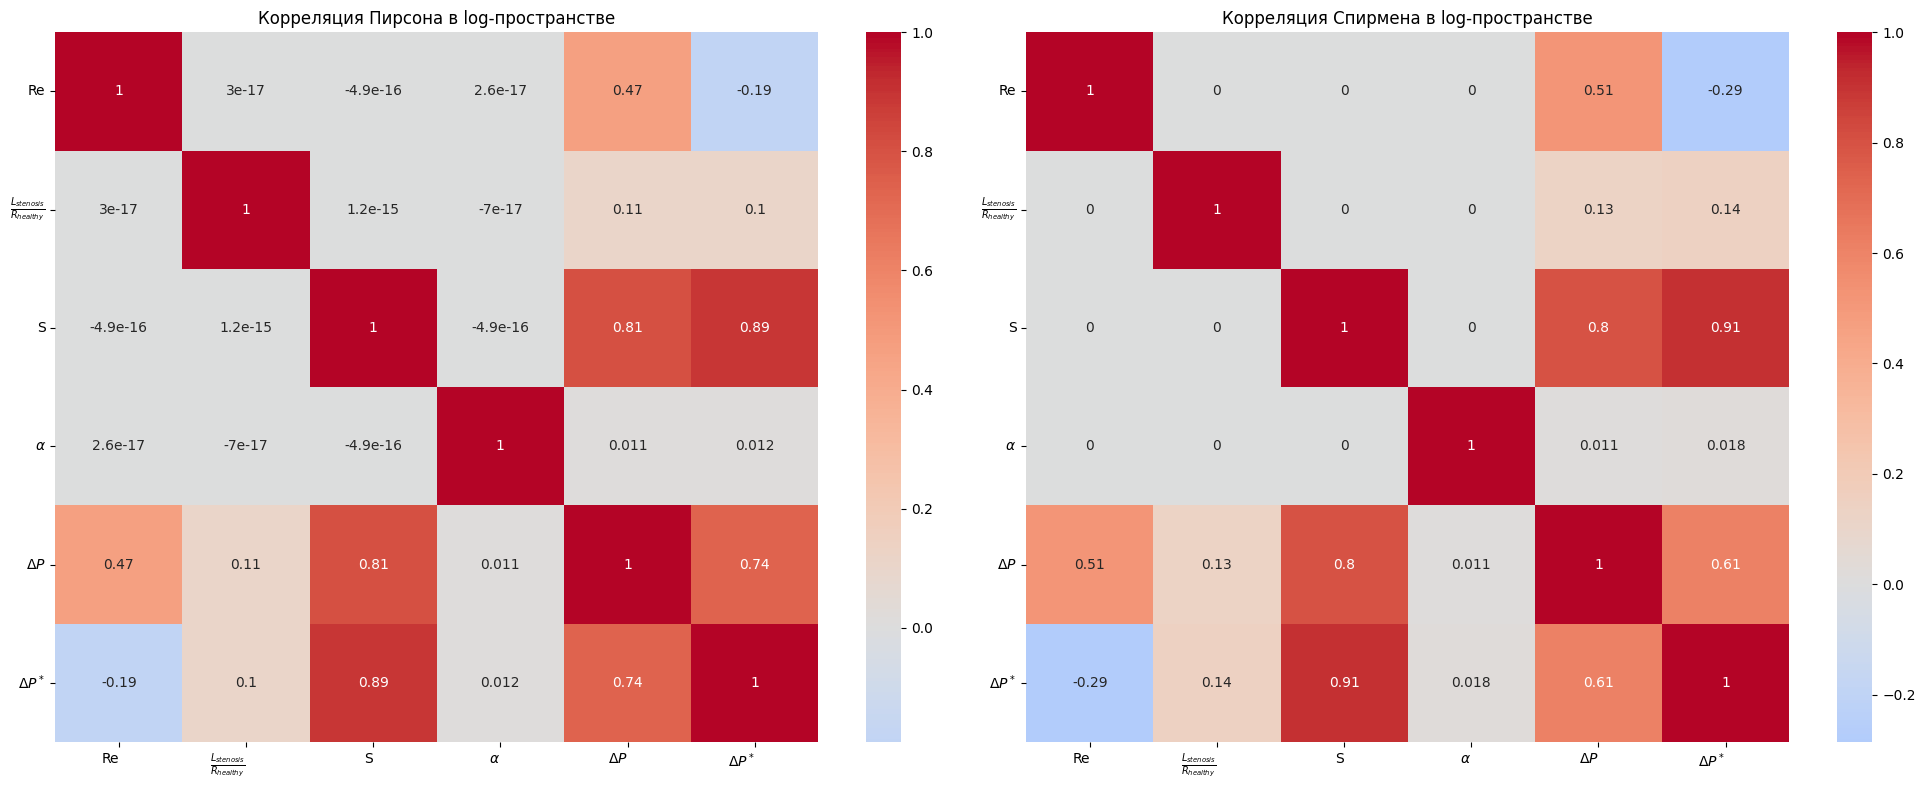

In [32]:
corr_pearson_log = df_num_log.corr(method='pearson')
corr_spearman_log = df_num_log.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_pearson_log, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Корреляция Пирсона в log-пространстве')

sns.heatmap(corr_spearman_log, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Корреляция Спирмена в log-пространстве')
# наклон подписей
for ax in axes:
    labels = [nice_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=0, ha='right')

    labels = [nice_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


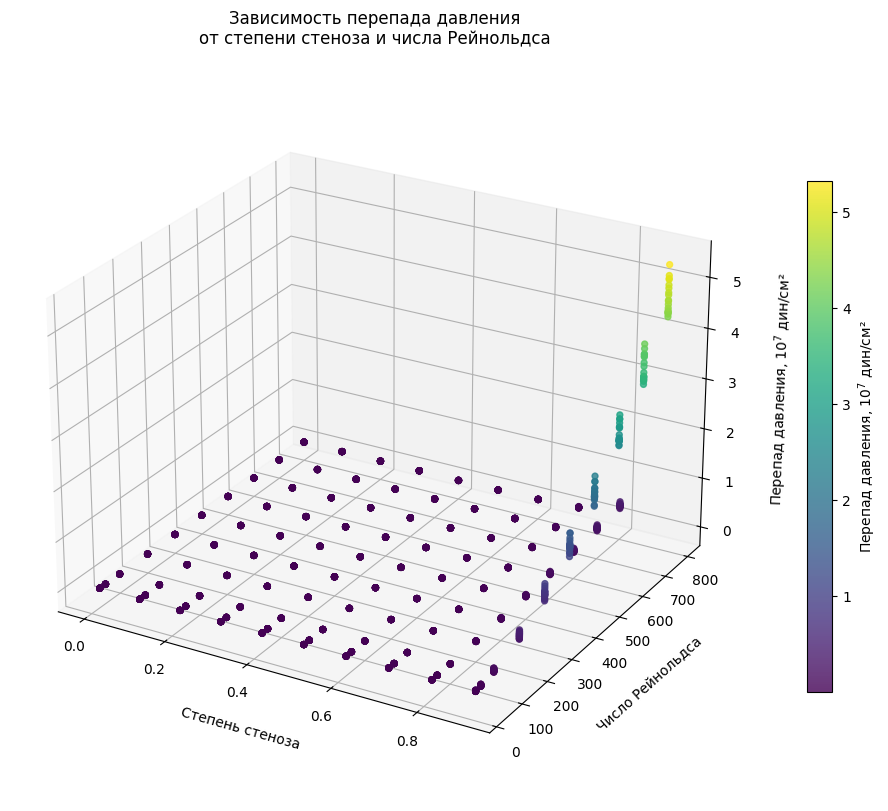

In [33]:
x = df['Degree of stenosis'].to_numpy()
y = df['Re'].to_numpy()
z = df['Pressure difference [dyn/cm^2]'].to_numpy()

z_scaled = z / 1e7

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x,
    y,
    z_scaled,
    c=z_scaled,
    s=18,
    alpha=0.8,
    depthshade=False
)

ax.set_xlabel('Степень стеноза', labelpad=10)
ax.set_ylabel('Число Рейнольдса', labelpad=10)
ax.set_zlabel('Перепад давления, $10^7$ дин/см²', labelpad=12)

ax.set_title(
    'Зависимость перепада давления\n'
    'от степени стеноза и числа Рейнольдса',
    pad=20
)

ax.view_init(elev=25, azim=-60)
ax.set_box_aspect((1.3, 1.2, 0.9))

cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.08)
cbar.set_label('Перепад давления, $10^7$ дин/см²')

plt.show()

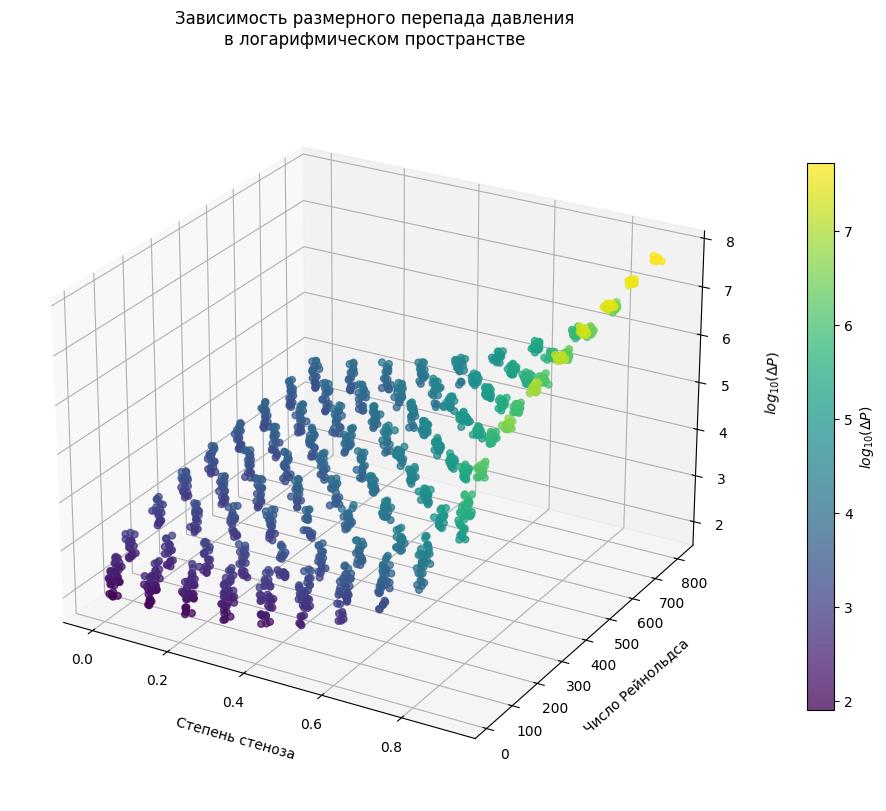

In [34]:
x = df['Degree of stenosis'].to_numpy()
y = df['Re'].to_numpy()

pressure = df['Pressure difference [dyn/cm^2]'].to_numpy()

# логарифм размерного перепада давления
z_log = np.log10(pressure)

rng = np.random.default_rng(42)
x_plot = x + rng.normal(0, 0.005, size=len(x))
y_plot = y + rng.normal(0, 5, size=len(y))

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x_plot,
    y_plot,
    z_log,
    c=z_log,
    s=24,
    alpha=0.75
)

ax.set_xlabel('Степень стеноза', labelpad=10)
ax.set_ylabel('Число Рейнольдса', labelpad=10)
ax.set_zlabel('$log_{10}(\\Delta P)$', labelpad=12)

ax.set_title(
    'Зависимость размерного перепада давления\n'
    'в логарифмическом пространстве',
    pad=20
)

ax.view_init(elev=25, azim=-60)
ax.set_box_aspect((1.2, 1.2, 0.9))

cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.08)
cbar.set_label('$log_{10}(\\Delta P)$')

plt.show()